Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully")

Libraries imported successfully


Load the dataset

In [3]:
df = pd.read_csv("ecommerce_sales_analytics.csv")
print("Dataset loaded successfully")

Dataset loaded successfully


Initial Data Inspection

In [4]:
df.head()

,order_id,order_date,customer_id,product_category,Age,Gender,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,01-01-2022,1102,Beauty,18,Male,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,01-02-2022,1435,Clothing,22,Male,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,01-03-2022,1860,Beauty,54,Female,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,01-04-2022,1270,Electronics,23,Male,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,01-05-2022,1106,Clothing,56,Female,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [5]:
print("Number of rows and columns")
print(df.shape)

Number of rows and columns
(1000, 14)


In [6]:
print("Data types")
print(df.dtypes)

Data types
order_id              int64
order_date              str
customer_id           int64
product_category        str
Age                   int64
Gender                  str
region                  str
quantity              int64
unit_price          float64
discount            float64
payment_method          str
delivery_days         int64
customer_rating     float64
revenue             float64
dtype: object


In [8]:
print("missing  values")
print(df.isnull().sum())

missing  values
order_id            0
order_date          0
customer_id         0
product_category    0
Age                 0
Gender              0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64


Descriptive Statistics

In [9]:
df.describe()

,order_id,customer_id,Age,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,10500.500000,1504.555000,46.465000,4.085000,303.232230,0.183300,6.130000,2.963600,1011.094600
std,288.819436,290.125045,14.885979,2.022341,171.366646,0.100006,3.104632,1.156647,825.565893
min,10001.000000,1000.000000,18.000000,1.000000,15.780000,0.000000,1.000000,1.000000,12.830000
25%,10250.750000,1242.750000,35.000000,2.000000,152.625000,0.100000,4.000000,2.000000,345.105000
50%,10500.500000,1506.000000,49.000000,4.000000,296.850000,0.190000,6.000000,3.000000,799.865000
75%,10750.250000,1758.000000,58.000000,6.000000,451.762500,0.270000,9.000000,3.900000,1485.480000
max,11000.000000,1998.000000,69.000000,7.000000,599.320000,0.350000,11.000000,5.000000,4119.330000


Time Series Analysis

Monthly Sales Trend

First,convert the Date column into date time format,calculate monthly sales , and plot the monthly sales trend using a line graph

In [10]:
print(df.columns.tolist())

['order_id', 'order_date', 'customer_id', 'product_category', 'Age', 'Gender', 'region', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'customer_rating', 'revenue']


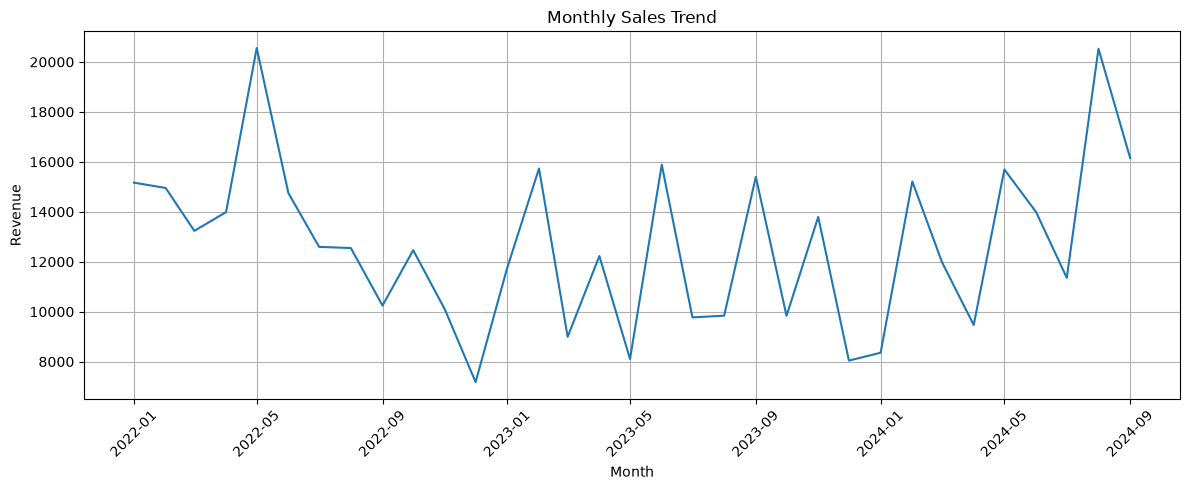

In [11]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['revenue'].sum()
monthly_sales.index=monthly_sales.index.to_timestamp()
plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index,monthly_sales.values)
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


The monthly revenue shows ups and downs over time.Some months have higher revenue and other months have lower revenue.

Quarterly Sales Trend

Firstly calculate quarterly sales and convert period to timestamp.plot quarterly sales trend.

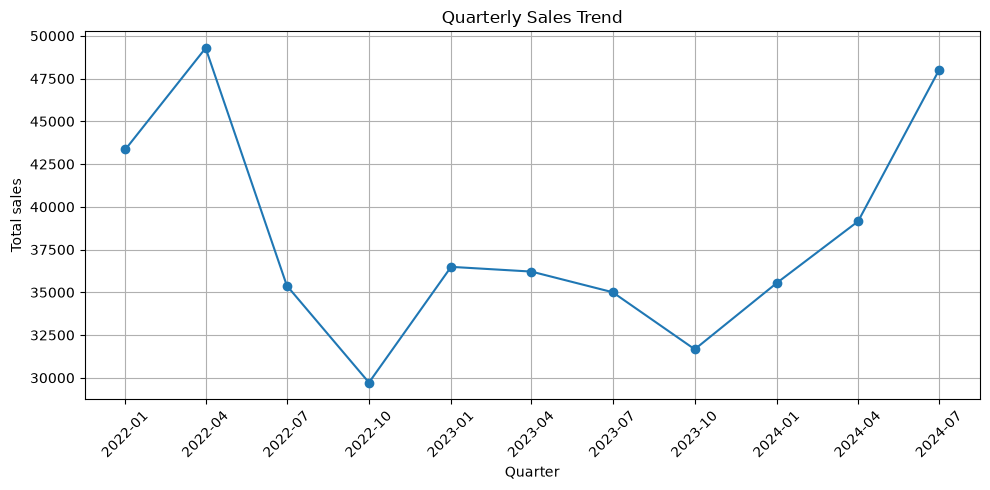

In [12]:
quarterly_sales = df.groupby(df['order_date'].dt.to_period('Q'))['revenue'].sum()
quarterly_sales.index = quarterly_sales.index.to_timestamp()
plt.figure(figsize=(10,5))
plt.plot(quarterly_sales.index,quarterly_sales.values,marker='o')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

observation: Sales started strong and increased to reach their highest peak in Q2.sales dropped sharply across Q3 and Q4.In Q5 sales recovered slightlyand flat through in Q6 and Q7 and again dropped in Q8.Finally Q9 onwards sales shows steady and strong continuous increase in Q10 and Q11. 

Customer Demographic Analysis

Customer Age Group

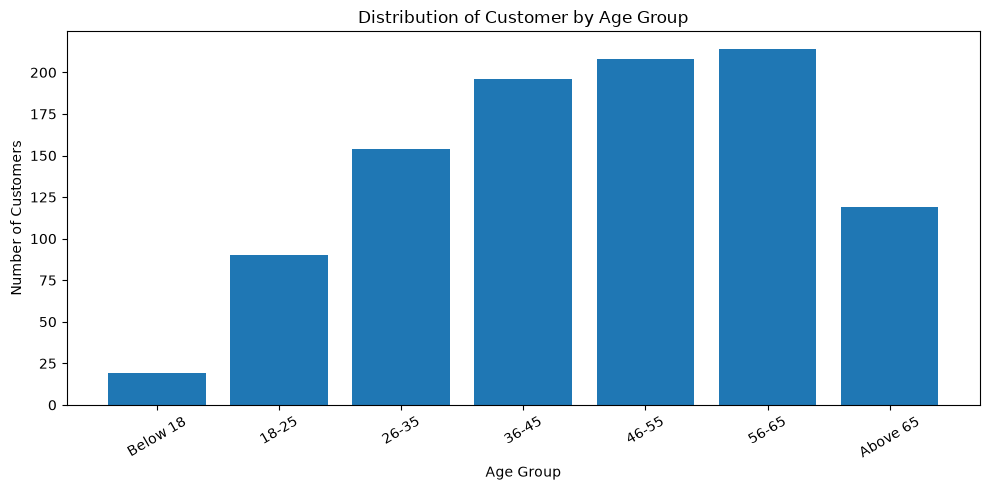

In [13]:
bins = [0,18,25,35,45,55,65,100]
labels = ['Below 18','18-25','26-35','36-45','46-55','56-65','Above 65']
df['Age Group'] = pd.cut(df['Age'],bins=bins,labels=labels,include_lowest=True)
age_group_counts = df['Age Group'].value_counts().sort_index()
plt.figure(figsize=(10,5))
plt.bar(age_group_counts.index.astype(str),age_group_counts.values)
plt.title('Distribution of Customer by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Observation: From the above table describe about the customers are from different age groups.

Gender Breakdown

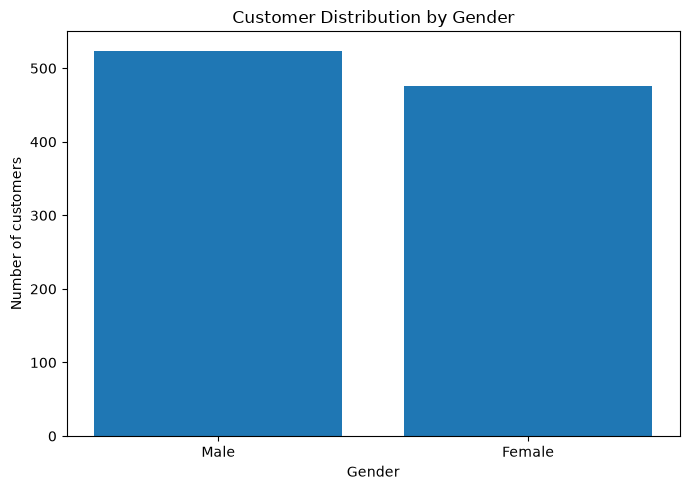

In [14]:
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(7,5))
plt.bar(gender_counts.index,gender_counts.values)
plt.title('Customer Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.show()

Product Analysis

Note: The dataset doesn't have product name column. so, instead of name ,I analyze product category based on quantity sold.

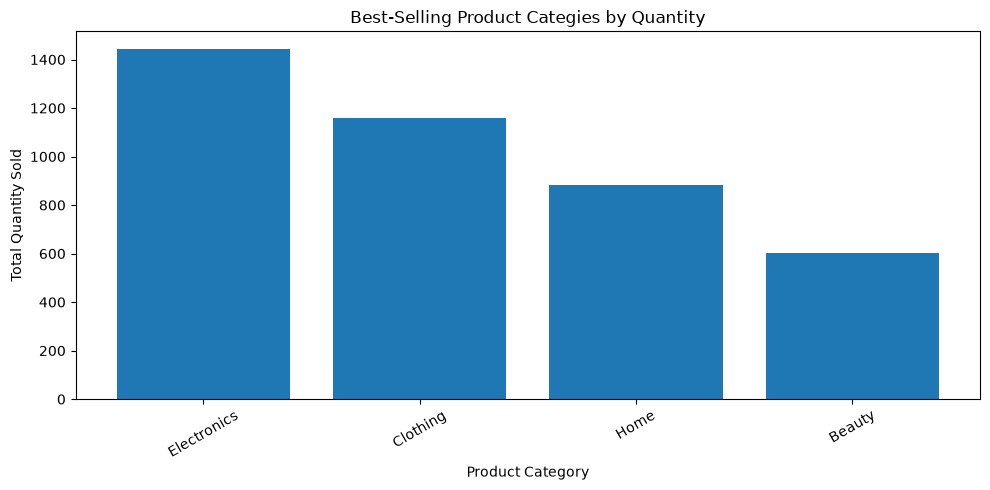

In [19]:
category_quantity = (df.groupby('product_category')['quantity'].sum().sort_values(ascending=False).head(10))
plt.figure(figsize=(10,5))
plt.bar(category_quantity.index,category_quantity.values)
plt.title('Best-Selling Product Categies by Quantity')
plt.xlabel('Product Category')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Revenue by Product Category

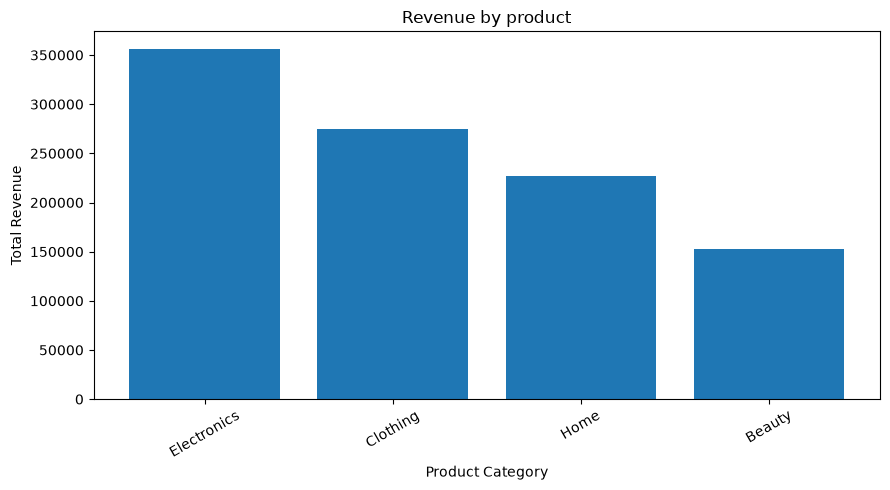

In [20]:
category_revenue = (df.groupby('product_category')['revenue'].sum().sort_values(ascending=False))
plt.figure(figsize=(9,5))
plt.bar(category_revenue.index,category_revenue.values)
plt.title('Revenue by product')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Correlation Heatmap

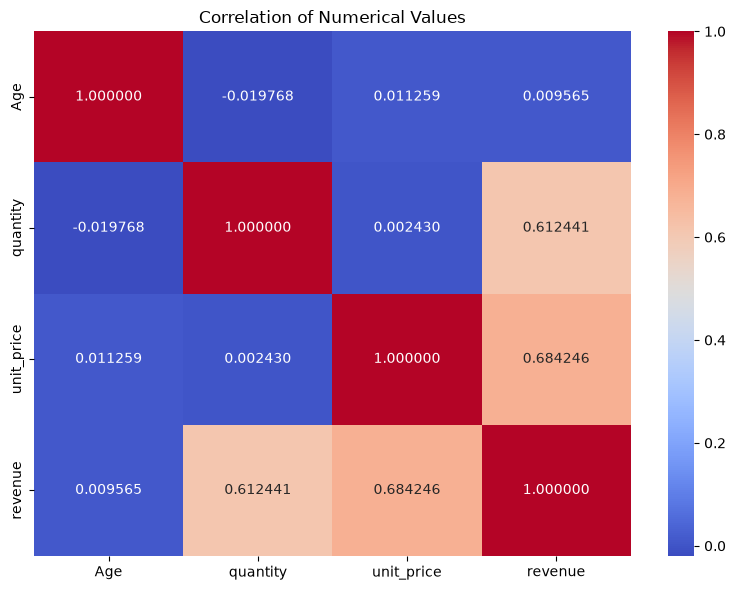

In [23]:
numerical_columns = ['Age','quantity','unit_price','revenue']
correlation_matrix = df[numerical_columns].corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='2f')
plt.title('Correlation of Numerical Values')
plt.tight_layout()
plt.show()

Additional Visualization
Spending by Age Group

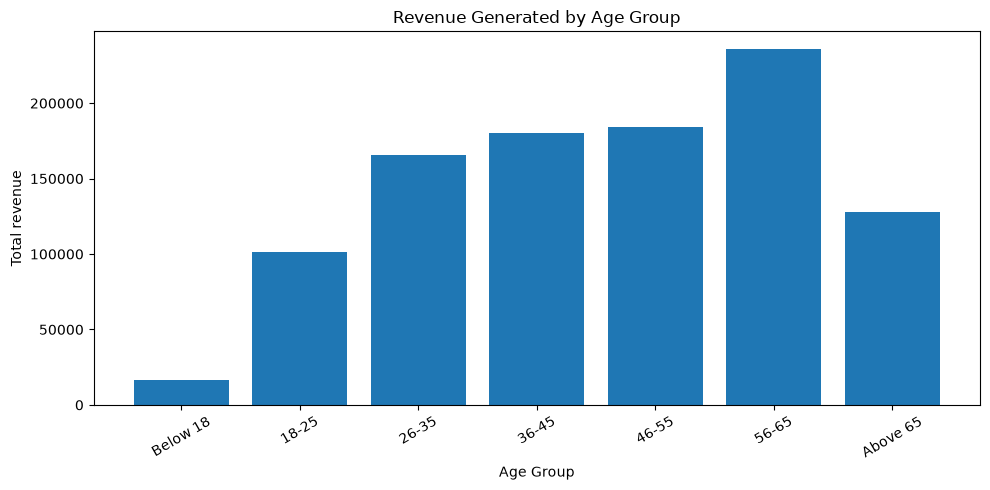

In [25]:
age_revenue = (df.groupby('Age Group',observed=True)['revenue'].sum())
plt.figure(figsize=(10,5))
plt.bar(age_revenue.index.astype(str),age_revenue.values)
plt.title('Revenue Generated by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total revenue')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()